# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


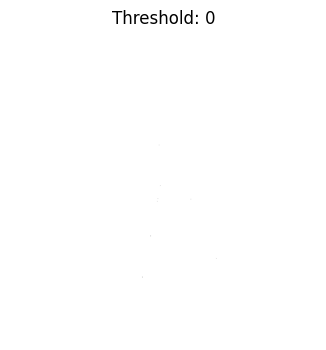

Threshold value: 50


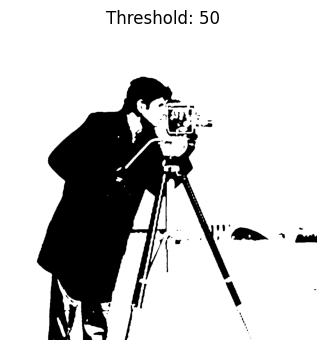

Threshold value: 100


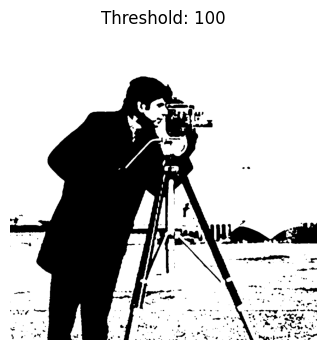

Threshold value: 150


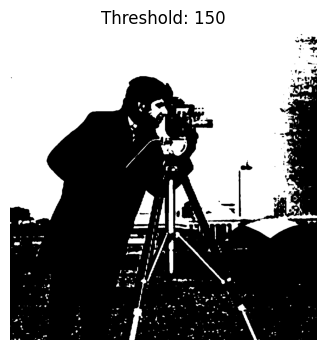

Threshold value: 200


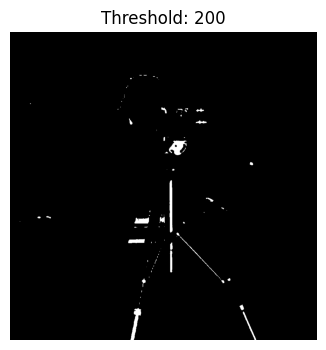

In [7]:
import cv2
import matplotlib.pyplot as plt
# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    _, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f'Threshold value: {threshold_value}')

    # Display the image using Matplotlib
    plt.figure(figsize=(4, 4))
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'Threshold: {threshold_value}')
    plt.axis('off')
    plt.show()

Original Image: 


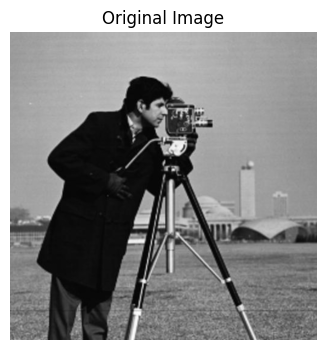

In [9]:
print('Original Image: ')
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

## Histograms

/opt/anaconda3/envs/p1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


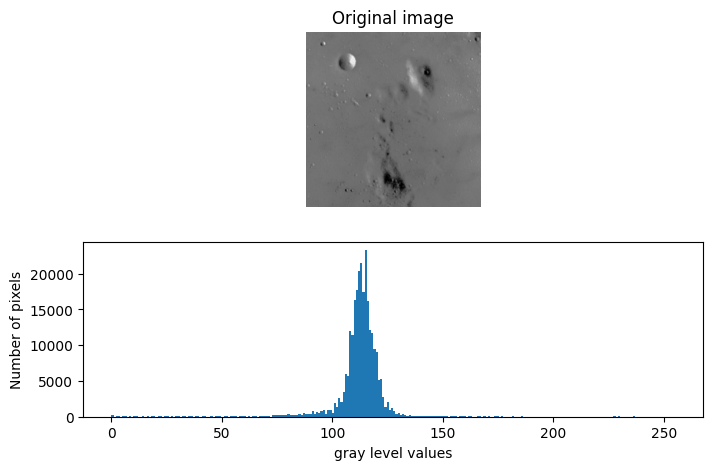

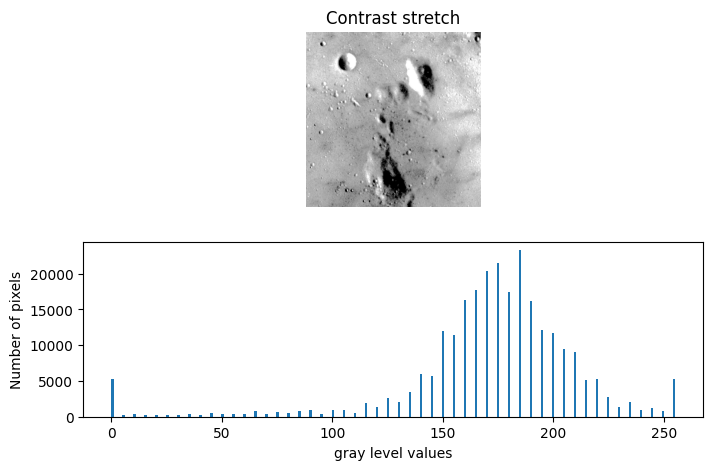

In [10]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


# Task 1

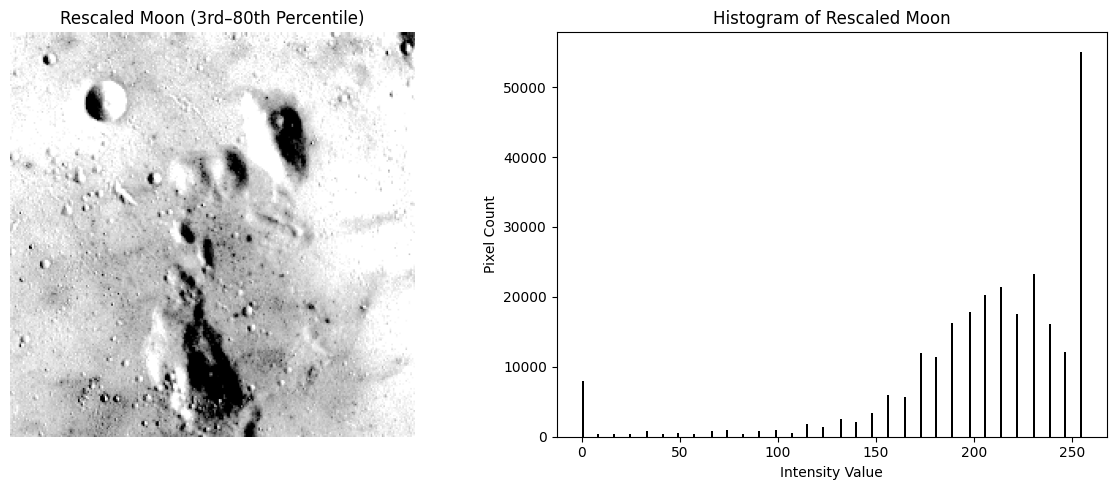

In [ ]:
import numpy as np
from skimage import data, exposure

moon_img = data.moon()

p3, p80 = np.percentile(moon_img, (3, 80))

rescaled_moon = exposure.rescale_intensity(
    moon_img, in_range=(p3, p80), out_range=(0, 255)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(rescaled_moon, cmap='gray')
axes[0].set_title('Rescaled Moon (3rd–80th Percentile)')
axes[0].axis('off')

axes[1].hist(rescaled_moon.ravel(), bins=256, range=(0, 255), color='black')
axes[1].set_title('Histogram of Rescaled Moon')
axes[1].set_xlabel('Intensity Value')
axes[1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

# Task 2


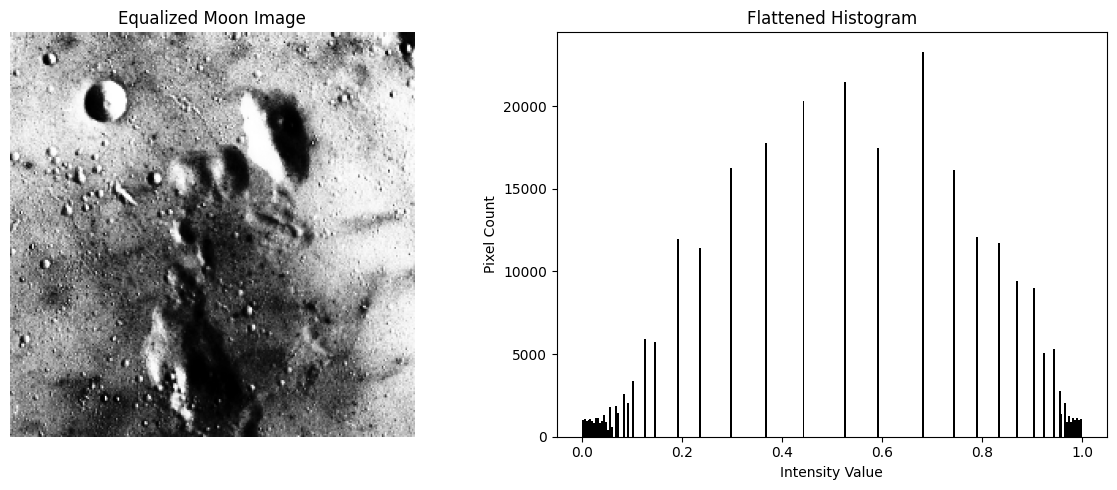

In [ ]:
# Histogram equalization
equalized_moon = exposure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(equalized_moon, cmap='gray')
axes[0].set_title('Equalized Moon Image')
axes[0].axis('off')

axes[1].hist(equalized_moon.ravel(), bins=256, range=(0, 1), color='black')
axes[1].set_title('Flattened Histogram')
axes[1].set_xlabel('Intensity Value')
axes[1].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

# Task 3

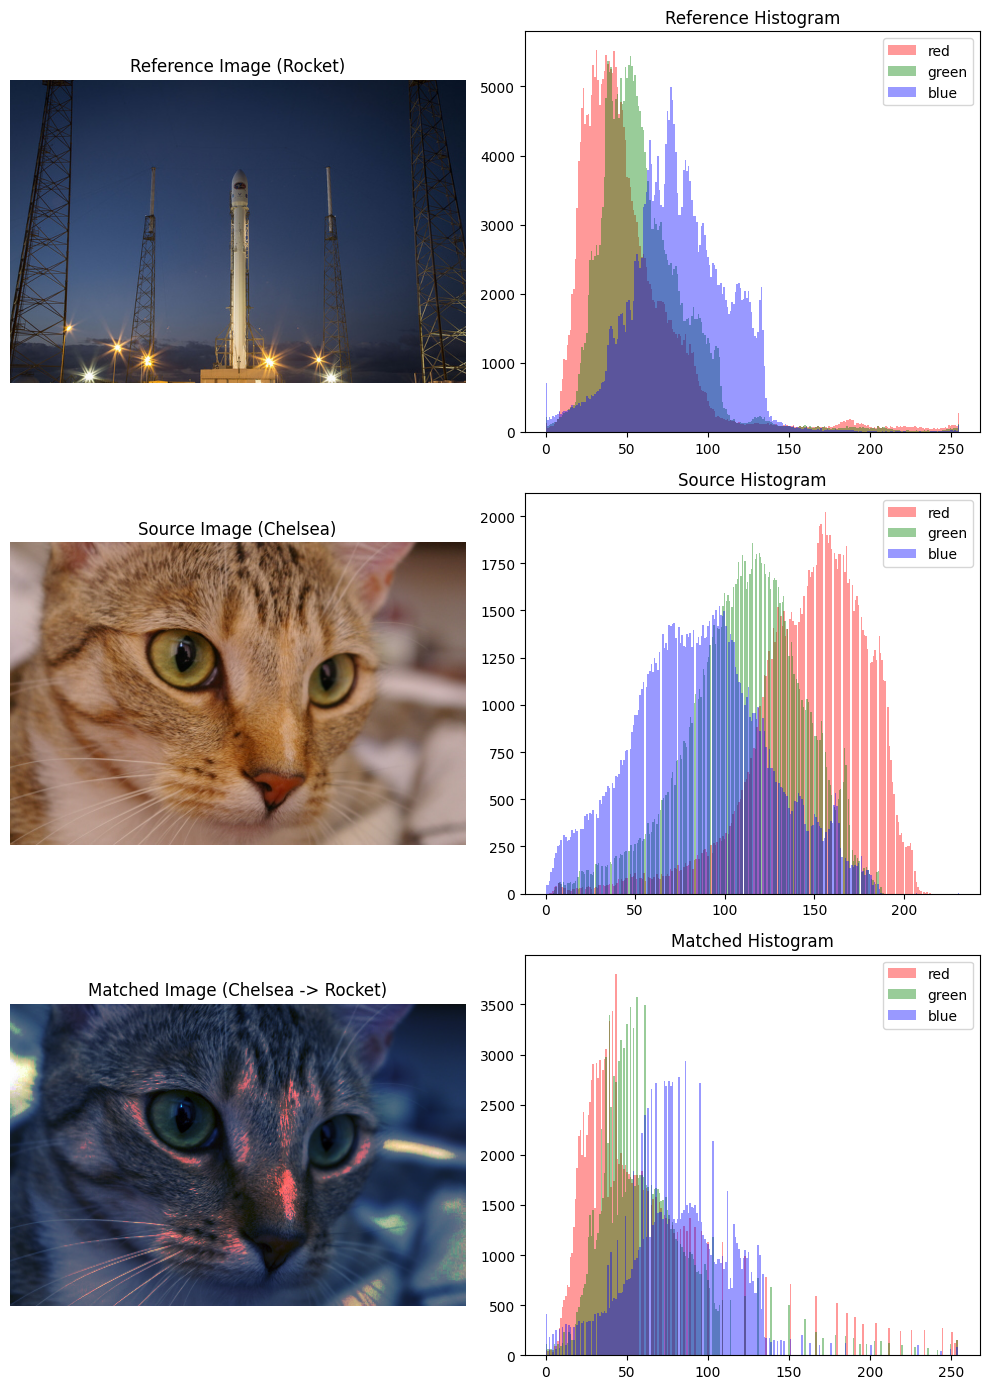

In [ ]:
reference = data.rocket()
image = data.chelsea()
matched_image = exposure.match_histograms(image, reference, channel_axis=-1)
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

axes[0, 0].imshow(reference)
axes[0, 0].set_title('Reference Image (Rocket)')
axes[0, 0].axis('off')
for i, color in enumerate(['red', 'green', 'blue']):
  axes[0, 1].hist(
      reference[:, :, i].ravel(),
      bins=256,
      color=color,
      alpha=0.4,
      label=color,
  )
axes[0, 1].set_title('Reference Histogram')
axes[0, 1].legend()

axes[1, 0].imshow(image)
axes[1, 0].set_title('Source Image (Chelsea)')
axes[1, 0].axis('off')
for i, color in enumerate(['red', 'green', 'blue']):
  axes[1, 1].hist(
      image[:, :, i].ravel(), bins=256, color=color, alpha=0.4, label=color
  )
axes[1, 1].set_title('Source Histogram')
axes[1, 1].legend()

axes[2, 0].imshow(matched_image)
axes[2, 0].set_title('Matched Image (Chelsea -> Rocket)')
axes[2, 0].axis('off')
for i, color in enumerate(['red', 'green', 'blue']):
  axes[2, 1].hist(
      matched_image[:, :, i].ravel(),
      bins=256,
      color=color,
      alpha=0.4,
      label=color,
  )
axes[2, 1].set_title('Matched Histogram')
axes[2, 1].legend()

plt.tight_layout()
plt.show()